In [1]:
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy, Amplitude, BettiCurve

# Active vs Inactive Substances: qHTS Assay for Inhibitors and Substrates of Cytochrome P450 3A4

In [2]:
import pandas as pd
import numpy as np

In [3]:
df1 = pd.read_csv("PubChem_active.csv")
df2 = pd.read_csv("PubChem_inactive.csv")
df1.head()

,Compound_CID,Name,Synonyms,Molecular_Weight,Molecular_Formula,Polar_Area,Complexity,XLogP,Heavy_Atom_Count,H-Bond_Donor_Count,...,Linked_PubChem_Patent_Count,Linked_PubChem_Patent_Family_Count,MeSH_Headings,Annotation_Content,Annotation_Type_Count,Linked_BioAssays,Create_Date,Data_Source,Data_Source_Category,Tagged_by_PubChem
0,3233816,N-[3-[4-(cyclopropylamino)quinazolin-2-yl]phen...,NCGC00011236|CHEMBL1490477|PCOP-408833,354.40,C18H18N4O2S,92.4,560.0,3.0,25,2,...,0,0,NaN,Biological Test Results|Classification|Literat...,4,346|348|357|410|411|444|445|446|447|448|450|45...,20050816,ABI Chem|ChEMBL|ChemSpider|Collaborative Drug ...,Chemical Vendors|Curation Efforts|Governmental...,NaN
1,3233844,"(4-methoxyphenyl)-[(5S)-2-pyridin-2-yl-2,7-dia...",NCGC00011264|CHEMBL1611806|PCOP-417927,351.40,C21H25N3O2,45.7,492.0,3.2,26,0,...,0,0,NaN,Biological Test Results|Classification|Literat...,4,346|348|357|410|411|444|445|446|447|448|451|52...,20050816,ABI Chem|ChEMBL|ChemSpider|MolGenie|National C...,Chemical Vendors|Curation Efforts|Governmental...,NaN
2,3233843,6-(3-methoxyphenyl)-N-[(5-methylpyrazin-2-yl)m...,NCGC00011263|CHEMBL1433559|PCOP-417822,357.40,C21H19N5O,72.8,464.0,3.2,27,1,...,0,0,NaN,Biological Test Results|Classification|Literat...,5,346|348|357|410|411|444|445|446|447|448|450|45...,20050816,ABI Chem|ChEMBL|ChemSpider|Collaborative Drug ...,Chemical Vendors|Curation Efforts|Governmental...,NaN
3,3233839,N-[(2-methoxyphenyl)methyl]-6-pyridin-3-ylpyri...,NCGC00011259|CHEMBL1377727|PCOP-416841,292.33,C17H16N4O,59.9,328.0,2.6,22,1,...,0,0,NaN,Biological Test Results|Classification|Literat...,5,346|348|357|410|411|444|445|446|447|448|450|45...,20050816,ABI Chem|ChEMBL|ChemSpider|Collaborative Drug ...,Chemical Vendors|Curation Efforts|Governmental...,NaN
4,3233837,"6-(3,5-Difluorophenyl)-2-(4-methoxyphenoxy)-8-...",NCGC00011257|CHEMBL1525456|PCOP-415574,396.30,C20H14F2N4O3,76.9,619.0,3.2,29,0,...,0,0,NaN,Biological Test Results|Classification|Literat...,4,346|348|357|410|411|444|445|446|447|448|450|45...,20050816,ABI Chem|ChEMBL|ChemSpider|MolGenie|National C...,Chemical Vendors|Curation Efforts|Governmental...,NaN


In [4]:
my_data = pd.read_csv("drugs_combined.csv")
my_data.head()

,Name,SMILES,target
0,N-[3-[4-(cyclopropylamino)quinazolin-2-yl]phen...,CS(=O)(=O)NC1=CC=CC(=C1)C2=NC3=CC=CC=C3C(=N2)N...,0
1,"(4-methoxyphenyl)-[(5S)-2-pyridin-2-yl-2,7-dia...",COC1=CC=C(C=C1)C(=O)N2CCC[C@]3(C2)CCN(C3)C4=CC...,0
2,6-(3-methoxyphenyl)-N-[(5-methylpyrazin-2-yl)m...,CC1=CN=C(C=N1)CNC2=NC=NC3=C2C=C(C=C3)C4=CC(=CC...,0
3,N-[(2-methoxyphenyl)methyl]-6-pyridin-3-ylpyri...,COC1=CC=CC=C1CNC2=NC=NC(=C2)C3=CN=CC=C3,0
4,"6-(3,5-Difluorophenyl)-2-(4-methoxyphenoxy)-8-...",CN1C2=NC(=NC=C2N=C(C1=O)C3=CC(=CC(=C3)F)F)OC4=...,0


In [5]:
my_data["Name_sp"] = my_data["Name"].str.split(']').str[-1].str.strip()
my_data.head(8)

,Name,SMILES,target,Name_sp
0,N-[3-[4-(cyclopropylamino)quinazolin-2-yl]phen...,CS(=O)(=O)NC1=CC=CC(=C1)C2=NC3=CC=CC=C3C(=N2)N...,0,methanesulfonamide
1,"(4-methoxyphenyl)-[(5S)-2-pyridin-2-yl-2,7-dia...",COC1=CC=C(C=C1)C(=O)N2CCC[C@]3(C2)CCN(C3)C4=CC...,0,methanone
2,6-(3-methoxyphenyl)-N-[(5-methylpyrazin-2-yl)m...,CC1=CN=C(C=N1)CNC2=NC=NC3=C2C=C(C=C3)C4=CC(=CC...,0,quinazolin-4-amine
3,N-[(2-methoxyphenyl)methyl]-6-pyridin-3-ylpyri...,COC1=CC=CC=C1CNC2=NC=NC(=C2)C3=CN=CC=C3,0,-6-pyridin-3-ylpyrimidin-4-amine
4,"6-(3,5-Difluorophenyl)-2-(4-methoxyphenoxy)-8-...",CN1C2=NC(=NC=C2N=C(C1=O)C3=CC(=CC(=C3)F)F)OC4=...,0,"6-(3,5-Difluorophenyl)-2-(4-methoxyphenoxy)-8-..."
5,5-(2-chlorophenyl)-N-[2-(5-methoxy-1H-indol-3-...,COC1=CC2=C(C=C1)NC=C2CCNC3=NC=NC=C3C4=CC=CC=C4Cl,0,pyrimidin-4-amine
6,N-[3-[4-(pyridin-4-ylamino)quinazolin-2-yl]phe...,CS(=O)(=O)NC1=CC=CC(=C1)C2=NC3=CC=CC=C3C(=N2)N...,0,methanesulfonamide
7,N-benzyl-2-(2-methoxyphenyl)pyrimidin-4-amine,COC1=CC=CC=C1C2=NC=CC(=N2)NCC3=CC=CC=C3,0,N-benzyl-2-(2-methoxyphenyl)pyrimidin-4-amine


In [6]:
my_names = my_data["Name_sp"].values
my_names = list(my_names)
my_smiles = my_data["SMILES"].values

In [7]:
# For Jupyter Notebook, use this quick-start code:
from rdkit import Chem
from rdkit.Chem import Draw
import networkx as nx
import matplotlib.pyplot as plt

# Quick visualization of SMILES
def quick_visualize(smiles_list, names=None):
    if names is None:
        names = [f"Compound {i+1}" for i in range(len(smiles_list))]
    
    mols = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            mols.append(mol)
    
    img = Draw.MolsToGridImage(mols, legends=names, molsPerRow=2)
    return img


# Active substances: Inhibitors and Substrates of Cytochrome P450 3A4

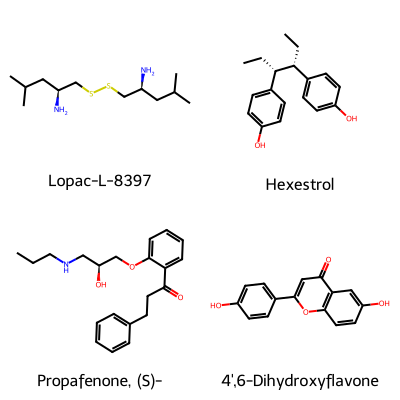

In [8]:
quick_visualize(my_smiles[1000:1004], my_names[1000:1004])

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

import matplotlib.pyplot as plt
import networkx as nx
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

def plot_simple_molecule_graph(smiles, save_path=None, figsize=(8, 6)):
    """
    Convert SMILES to graph and plot it.
    
    Args:
        smiles (str): SMILES string
        save_path (str): Path to save the plot (e.g., 'molecule.png')
        figsize (tuple): Figure size
    
    Returns:
        tuple: (fig, axes, G) - matplotlib figure, axes, and NetworkX graph
    """
    # Convert SMILES to molecule
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"Invalid SMILES: {smiles}")
        return None
    
    # Generate 2D coordinates
    mol = Chem.AddHs(mol)  # Add hydrogens for better visualization
    AllChem.Compute2DCoords(mol)
    
    # Create graph
    G = nx.Graph()
    pos = {}  # Store node positions
    
    # Add atoms as nodes with positions
    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        G.add_node(idx, symbol=atom.GetSymbol())
        
        # Get 2D coordinates
        conf = mol.GetConformer()
        pos[idx] = (conf.GetAtomPosition(idx).x, conf.GetAtomPosition(idx).y)
    
    # Add bonds as edges
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        G.add_edge(i, j)
    
    # Create plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: NetworkX graph
    labels = {i: G.nodes[i]['symbol'] for i in G.nodes()}
    
    nx.draw(G, pos, ax=ax1, with_labels=True, labels=labels,
            node_color='lightblue', node_size=500, 
            font_size=10, font_weight='bold',
            edge_color='gray', width=2)
    
    ax1.set_title(f"Graph Representation\n{smiles}")
    ax1.axis('equal')
    
    # Plot 2: RDKit structure
    mol_no_h = Chem.RemoveHs(mol)  # Remove hydrogens for cleaner view
    img = Draw.MolToImage(mol_no_h, size=(300, 300))
    ax2.imshow(img)
    ax2.axis('off')
    ax2.set_title("Chemical Structure")
    
    plt.tight_layout()
    
    # Save plot if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
    
    plt.show()
    
    return fig, (ax1, ax2), G

Plot saved to: smiles2graph_n2.jpg


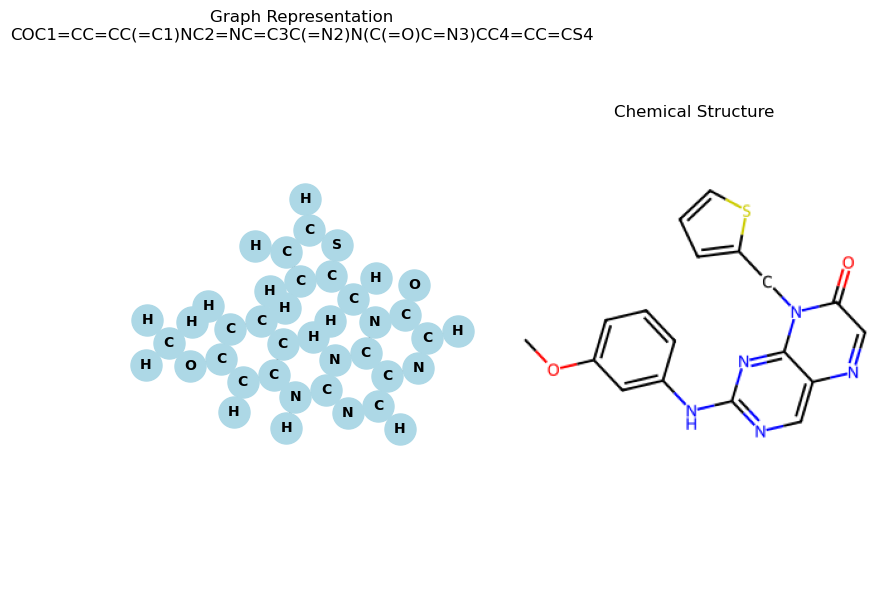

(<Figure size 800x600 with 2 Axes>,
 (<Axes: title={'center': 'Graph Representation\nCOC1=CC=CC(=C1)NC2=NC=C3C(=N2)N(C(=O)C=N3)CC4=CC=CS4'}>,
  <Axes: title={'center': 'Chemical Structure'}>),
 <networkx.classes.graph.Graph at 0x12d0511b8a0>)

In [41]:
save_path = "smiles2graph_n2.jpg"
plot_simple_molecule_graph(my_smiles[500], save_path)

# Inactive substances: Inhibitors and Substrates of Cytochrome P450 3A4

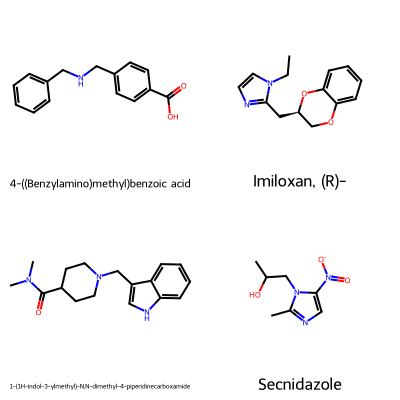

In [22]:
quick_visualize(my_smiles[6000:6004], my_names[6000:6004])

# Topological and Geometrical features:
* Spectral features
    * eigenvalues of weighted zero and 1-Laplacians (look up the library called toponetx for the 1-Laplacians eigenvalues)
  * spectral range
  * algebraic connectivity
* Persistent entropy
* Carlsson Coordinates
* Amplitudes metrics:
    * Wasserstein
    * Bottleneck
    * Landscape 
* Graph statistics:
    * transitivity
    * mean degree, max degree, etc.
    * cycle lengths
    * diameter and average path length 

In [ ]:
# For zero Laplacian, you can compute first 5 smallest non-zero eigenvalues
# For 1-Laplacian, compute first 5 smallest non-zero eigenvalues

# Training (Scaffold-split) with topological and geometrical features

In [1]:
import numpy as np
import networkx as nx
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns
#from new_features import  DiscriminativeFeatureGenerator
#from enhanced_features import DiscriminativeFeatureGenerator
from feature_gen import DiscriminativeFeatureGenerator
import warnings

warnings.filterwarnings('ignore')

# Try to import TopoModelX, but provide fallbacks
TOPONETX_AVAILABLE = False
try:
    import toponetx as tnx
    TOPONETX_AVAILABLE = True
    print("✓ TopoModelX successfully imported")
except ImportError as e:
    print(f"✗ TopoModelX not available: {e}")
    print("  Using fallback methods for 1-Laplacian computation")


✓ TopoModelX successfully imported


In [3]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import random
# ======================================================================
# 1. SCAFFOLD SPLITTING
# ======================================================================
def compute_scaffold(smiles):
    """Return Murcko scaffold SMILES; return None for invalid SMILES"""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)
    except:
        return None




def scaffold_split(df, test_size=0.2, random_state=36):
    scaffolds = {}
    for idx, s in enumerate(df["SMILES"]):
        scaffold = compute_scaffold(s)
        if scaffold is None:
            scaffold = f"NOSCAFFOLD_{idx}"
        scaffolds.setdefault(scaffold, []).append(idx)

    scaffold_groups = list(scaffolds.values())
    
    # Shuffle scaffold groups reproducibly
    rng = random.Random(random_state)
    rng.shuffle(scaffold_groups)

    n_total = len(df)
    n_test_target = int(test_size * n_total)

    test_idx = []
    train_idx = []
    running_count = 0

    for group in scaffold_groups:
        if running_count < n_test_target:
            test_idx.extend(group)
            running_count += len(group)
        else:
            train_idx.extend(group)

    return train_idx, test_idx


# ======================================================================
# 2. GRAPH CONVERTER
# ======================================================================
class SMILESToGraphConverter:
    """Convert SMILES strings to adjacency matrices"""

    def __init__(self, max_atoms=100):
        self.max_atoms = max_atoms

    def smiles_to_adjacency(self, smiles):
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                return np.zeros((self.max_atoms, self.max_atoms))

            mol = Chem.AddHs(mol)
            n_atoms = min(mol.GetNumAtoms(), self.max_atoms)

            adjacency = np.zeros((self.max_atoms, self.max_atoms))

            for i in range(n_atoms):
                atom_i = mol.GetAtomWithIdx(i)
                adjacency[i, i] = atom_i.GetAtomicNum() / 10.0  # Normalize atom numbers

                for j in range(i + 1, n_atoms):
                    bond = mol.GetBondBetweenAtoms(i, j)
                    if bond:
                        bt = bond.GetBondType()
                        if bt == Chem.rdchem.BondType.SINGLE:
                            w = 1.0
                        elif bt == Chem.rdchem.BondType.DOUBLE:
                            w = 2.0
                        elif bt == Chem.rdchem.BondType.TRIPLE:
                            w = 3.0
                        elif bt == Chem.rdchem.BondType.AROMATIC:
                            w = 1.5
                        else:
                            w = 1.0
                        adjacency[i, j] = adjacency[j, i] = w

            return adjacency

        except Exception as e:
            print(f"Error converting SMILES {smiles}: {e}")
            return np.zeros((self.max_atoms, self.max_atoms))

    def convert_smiles_list(self, smiles_list):
        adjacency_matrices = []
        valid_indices = []

        for i, sm in enumerate(smiles_list):
            if pd.isna(sm):
                continue
            adj = self.smiles_to_adjacency(sm)
            adjacency_matrices.append(adj)
            valid_indices.append(i)

        return adjacency_matrices, valid_indices




# ======================================================================
# 4. MAIN PIPELINE
# ======================================================================
class DrugClassificationPipeline:
    def __init__(self, n_bins=20, max_atoms=100, n_laplacian_eigenvalues=3,
                 test_size=0.2, random_state=42):

        self.n_bins = n_bins
        self.max_atoms = max_atoms
        self.test_size = test_size
        self.random_state = random_state

        self.graph_converter = SMILESToGraphConverter(max_atoms = max_atoms)
        self.feature_generator = DiscriminativeFeatureGenerator(n_bins=n_bins) # n_laplacian_eigenvalues = n_laplacian_eigenvalues)

        self.label_encoder = LabelEncoder()
        self.models = {}
        self.results = {}
        self.class_names = None

    # ----------------------------------------------------------
    def load_data(self):
        df = pd.read_csv("drugs_combined.csv")
        return df

    # ----------------------------------------------------------
    def preprocess_data(self, df):
        df_clean = df.dropna(subset=["SMILES", "target"])
        return df_clean

    # ----------------------------------------------------------
    def prepare_features(self, df):
        smiles_list = df["SMILES"].tolist()
        targets = df["target"].tolist()

        adjacency_matrices, valid_indices = self.graph_converter.convert_smiles_list(smiles_list)
        valid_targets = [targets[i] for i in valid_indices]
        valid_df = df.iloc[valid_indices].reset_index(drop=True)

        X, y, feature_info = self.feature_generator.fit_transform(adjacency_matrices, valid_targets)

        # Encode labels
        if isinstance(valid_targets[0], str):
            y_encoded = self.label_encoder.fit_transform(valid_targets)
            self.class_names = self.label_encoder.classes_
        else:
            y_encoded = np.array(valid_targets)
            self.class_names = sorted(np.unique(valid_targets))

        return X, y_encoded, valid_df, feature_info

    # ----------------------------------------------------------RandomForestClassifier(
      #          n_estimators=400, max_depth=25, class_weight="balanced", n_jobs=-1
           # )
    def train_models(self, X_train, X_test, y_train, y_test):
        
        models = {
            "Random Forest": RandomForestClassifier(
                n_estimators=400, max_depth=25, class_weight="balanced", n_jobs=-1
            ),
            "SVM": SVC(probability=True, class_weight="balanced")
        }

        results = {}

        for name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            cv = cross_val_score(model, X_train, y_train, cv=5)

            results[name] = {
                "model": model,
                "y_pred": y_pred,
                "accuracy": acc,
                "cv_mean": cv.mean(),
                "cv_std": cv.std()
            }

            print(f"{name} Accuracy = {acc:.4f}, CV = {cv.mean():.4f}")

        self.results = results
        self.models = models

    # ----------------------------------------------------------
    def run_pipeline(self):
        df = self.load_data()
        df = self.preprocess_data(df)

        # Scaffold split
        train_idx, test_idx = scaffold_split(df, test_size=self.test_size,
                                             random_state=self.random_state)

        df_train = df.iloc[train_idx].reset_index(drop=True)
        df_test = df.iloc[test_idx].reset_index(drop=True)

        # Prepare features
        X_train, y_train, _, _ = self.prepare_features(df_train)
        X_test, y_test, _, _ = self.prepare_features(df_test)

        # Train + evaluate
        self.train_models(X_train, X_test, y_train, y_test)

        return X_train, y_train, X_test,y_test, train_idx, test_idx


if __name__ == "__main__":
    print("=" * 70)
    print("ENHANCED DRUG CLASSIFICATION PIPELINE WITH ADVANCED TOPOLOGY")
    print("=" * 70)
    print(f"TopoModelX Available: {TOPONETX_AVAILABLE}")
    
    # Initialize and run pipeline
    pipeline = DrugClassificationPipeline(
        n_bins=20, 
        max_atoms=100, 
        n_laplacian_eigenvalues=3,
        test_size=0.2, 
        random_state=42
    )
    
    print("\nPipeline Configuration:")
    print(f"- Number of filtration steps: {pipeline.n_bins}")
    print(f"- Maximum atoms per molecule: {pipeline.max_atoms}")
    #print(f"- 1-Laplacian eigenvalues: {pipeline.n_laplacian_eigenvalues}")
    #print(f"- Test set size: {pipeline.test_size}")
    #print(f"- Random state: {pipeline.random_state}")
    
    
        # Run the complete pipeline
    X_train, y_train, X_test, y_test, train_idx, test_idx = pipeline.run_pipeline()
        
        

ENHANCED DRUG CLASSIFICATION PIPELINE WITH ADVANCED TOPOLOGY
TopoModelX Available: True

Pipeline Configuration:
- Number of filtration steps: 20
- Maximum atoms per molecule: 100
Generating discriminative features...
Determining feature dimension...
Feature dimension: 52
Giotto-TDA available: True
Processing graph 1/5374
Processing graph 501/5374
Processing graph 1001/5374
Processing graph 1501/5374
Processing graph 2001/5374
Processing graph 2501/5374
Processing graph 3001/5374
Processing graph 3501/5374
Processing graph 4001/5374
Processing graph 4501/5374
Processing graph 5001/5374
Features shape: (5374, 52)
Total features: 52
Feature extraction completed for 5374 molecules
Generating discriminative features...
Processing graph 1/1565
Processing graph 501/1565
Processing graph 1001/1565
Processing graph 1501/1565
Features shape: (1565, 52)
Total features: 52
Feature extraction completed for 1565 molecules
Random Forest Accuracy = 0.6466, CV = 0.6863
SVM Accuracy = 0.7272, CV = 0.69